# Proyecto final

# Herramientas estadística e informácicas para la gestión energética

Presentado por:
Iveth Daniela Arango Naranjo,
Valentina Rodriguez bonilla,
Fabián David López Burbano.

# Pregunta problema:

## ¿Cuál es el comportamiento y la variabilidad temporal del recurso eólico en el departamento de La Guajira y qué efecto tiene sobre el potencial de generación de energía eléctrica?

Vamos a evaluar el comportomamiento y la variabilidad en el departamento de la Guajira, para así poder analizar el potencial de generación de energía eléctrica.

In [1]:
import sys
!{sys.executable} -m pip install requests pandas numpy matplotlib seaborn scipy ipykernel

In [2]:
#Libererías que vamos a usar
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Obtención de datos reales desde NASA POWER

NASA POWER es una plataforma que permite tomar información metereológica y climatológica para cualquier unicación del planeta

Vamos a descargar:

* Velocidad del viento a 2 metros (WS2M)

# Para descar los datos seguimos estos pasos:

* Solicitar los datos a la API de NASA.
* Recibir la respuesta en formaton JSON.
* Convertir el JSON a un Dataframe.
* Aplicar herramientas estadísticas para extraer conocimiento.

In [3]:
lat = 12.218014
lon = -72.059944

start_date = "20150101"
end_date = "20251231"

In [4]:
url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    "?parameters=T2M,WS2M"
    "&community=RE"
    f"&latitude={lat}"
    f"&longitude={lon}"
    f"&start={start_date}"
    f"&end={end_date}"
    "&format=JSON"
)

url

'https://power.larc.nasa.gov/api/temporal/hourly/point?parameters=T2M,WS2M&community=RE&latitude=12.218014&longitude=-72.059944&start=20150101&end=20251231&format=JSON'

In [5]:
url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    "?parameters=WS2M"
    "&community=RE"
    f"&latitude={lat}"
    f"&longitude={lon}"
    f"&start={start_date}"
    f"&end={end_date}"
    "&format=JSON"
)

response = requests.get(url)
data = response.json()

viento = data["properties"]["parameter"]["WS2M"]

df = pd.DataFrame({    
    "Velocidad_Viento": viento
})

# Conjunto de datos

Antes de realizar calculos estadísticos o construir gráficos debemos conocer lo siguiente:

* Número de registros.
* Variables disponibles.
* Tipo de información.
* Calidad de los datos.

In [6]:
df.head()

,Velocidad_Viento
2015010100,7.03
2015010101,7.16
2015010102,7.11
2015010103,7.12
2015010104,7.21


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 96432 entries, 2015010100 to 2025123123
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Velocidad_Viento  96432 non-null  float64
dtypes: float64(1)
memory usage: 1.5+ MB


In [8]:
df.shape

(96432, 1)

# Convertir el JSON a una tabla

Para realizar un análisis mas facilmente realizamos esta transformación.

In [9]:
# Convertir JSON a un Dataframe

df = pd.DataFrame(
    response.json()["properties"]["parameter"]["WS2M"].items(),
    columns=["Fecha", "Velocidad_Viento"])

# Convertir la fecha a formato datetime
df["Fecha"] = pd.to_datetime(
    df["Fecha"], format="%Y%m%d%H"

)

df


,Fecha,Velocidad_Viento
0,2015-01-01 00:00:00,7.03
1,2015-01-01 01:00:00,7.16
2,2015-01-01 02:00:00,7.11
3,2015-01-01 03:00:00,7.12
4,2015-01-01 04:00:00,7.21
...,...,...
96427,2025-12-31 19:00:00,6.18
96428,2025-12-31 20:00:00,6.23
96429,2025-12-31 21:00:00,6.24
96430,2025-12-31 22:00:00,6.36


## Análisis exploratorio del recurso eólico

El conjunto de datos contiene Velocidad_Viento (WS2M), por eso, el análisis siguiente estudia la velocidad del viento como indicador del recurso eólico. Si en el futuro se dispone también de la dirección del viento (WD2M), este análisis podría complementarse con una rosa de vientos que identifique las direcciones predominantes del recurso.

En esta sección se calculan estadísticas descriptivas, promedios por mes y año, variabilidad mensual, años y meses extremos, y la tendencia temporal.

In [10]:
# Preparación y validación de la serie temporal
# Se trabaja con una copia para conservar el DataFrame original.
analisis = df.copy()

analisis["Fecha"] = pd.to_datetime(analisis["Fecha"], errors="coerce")
analisis["Velocidad_Viento"] = pd.to_numeric(
    analisis["Velocidad_Viento"], errors="coerce"
)

analisis = (
    analisis.dropna(subset=["Fecha", "Velocidad_Viento"])
    .sort_values("Fecha")
    .set_index("Fecha")
)

# Los valores negativos no representan una velocidad física válida.
analisis.loc[analisis["Velocidad_Viento"] < 0, "Velocidad_Viento"] = np.nan
analisis = analisis.dropna(subset=["Velocidad_Viento"])

variable = "Velocidad_Viento"
unidad = "m/s"

print(f"Periodo analizado: {analisis.index.min():%Y-%m-%d} a {analisis.index.max():%Y-%m-%d}")
print(f"Registros válidos: {len(analisis):,}")
print(f"Datos faltantes en la variable: {analisis[variable].isna().sum():,}")
analisis.head()

Periodo analizado: 2015-01-01 a 2025-12-31
Registros válidos: 96,432
Datos faltantes en la variable: 0


,Velocidad_Viento
Fecha,
2015-01-01 00:00:00,7.03
2015-01-01 01:00:00,7.16
2015-01-01 02:00:00,7.11
2015-01-01 03:00:00,7.12
2015-01-01 04:00:00,7.21


In [11]:
# 1. Estadísticas descriptivas de la velocidad del viento
estadisticas = analisis[variable].describe().to_frame(name=variable)
estadisticas.loc["mediana"] = analisis[variable].median()
estadisticas.loc["coef_variacion_%"] = (
    analisis[variable].std() / analisis[variable].mean() * 100
)

print("Estadísticas descriptivas")
display(estadisticas.round(3))

Estadísticas descriptivas


,Velocidad_Viento
count,96432.000
mean,5.917
std,1.834
min,0.040
25%,4.770
50%,6.140
75%,7.270
max,10.900
mediana,6.140
coef_variacion_%,30.989


In [12]:
#Promedios climatológicos por mes y por año
analisis["Año"] = analisis.index.year
analisis["Mes"] = analisis.index.month

nombres_meses = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

promedio_mensual = (
    analisis.groupby("Mes")[variable]
    .agg(Promedio="mean", Desviacion="std", Minimo="min", Maximo="max")
)
promedio_mensual["Mes"] = promedio_mensual.index.map(nombres_meses)
promedio_mensual = promedio_mensual[["Mes", "Promedio", "Desviacion", "Minimo", "Maximo"]]

promedio_anual = (
    analisis.groupby("Año")[variable]
    .agg(Promedio="mean", Desviacion="std", Minimo="min", Maximo="max", Registros="count")
    .sort_index()
)

print("Promedio climatológico mensual")
display(promedio_mensual.round(3))
print("Promedio anual")
display(promedio_anual.round(3))

Promedio climatológico mensual


,Mes,Promedio,Desviacion,Minimo,Maximo
Mes,,,,,
1,Enero,5.984,1.564,0.83,10.87
2,Febrero,6.409,1.512,0.43,10.06
3,Marzo,6.424,1.516,1.28,10.76
4,Abril,6.527,1.381,0.71,10.42
5,Mayo,6.767,1.558,0.99,10.31
6,Junio,6.924,1.597,0.06,10.70
7,Julio,6.988,1.292,0.46,10.90
8,Agosto,5.975,1.663,0.22,10.29
9,Septiembre,4.697,1.721,0.04,9.43


Promedio anual


,Promedio,Desviacion,Minimo,Maximo,Registros
Año,,,,,
2015,6.798,1.671,0.37,10.70,8760
2016,5.791,1.875,0.08,10.27,8784
2017,5.580,1.843,0.14,10.00,8760
2018,6.398,1.582,0.17,10.50,8760
2019,5.967,1.815,0.04,10.23,8760
2020,5.912,1.869,0.13,10.87,8784
2021,6.268,1.521,0.47,10.90,8760
2022,5.655,1.856,0.08,10.64,8760
2023,5.709,1.905,0.09,9.93,8760


In [13]:
#Identificar el mejor y el peor año y mes
mejor_anio = promedio_anual["Promedio"].idxmax()
peor_anio = promedio_anual["Promedio"].idxmin()
mejor_mes_numero = promedio_mensual["Promedio"].idxmax()
peor_mes_numero = promedio_mensual["Promedio"].idxmin()

print(f"Mejor año: {mejor_anio} ({promedio_anual.loc[mejor_anio, 'Promedio']:.2f} {unidad})")
print(f"Peor año: {peor_anio} ({promedio_anual.loc[peor_anio, 'Promedio']:.2f} {unidad})")
print(
    f"Mejor mes: {nombres_meses[mejor_mes_numero]} "
    f"({promedio_mensual.loc[mejor_mes_numero, 'Promedio']:.2f} {unidad})"
)
print(
    f"Peor mes: {nombres_meses[peor_mes_numero]} "
    f"({promedio_mensual.loc[peor_mes_numero, 'Promedio']:.2f} {unidad})"
)

Mejor año: 2015 (6.80 m/s)
Peor año: 2024 (5.18 m/s)
Mejor mes: Julio (6.99 m/s)
Peor mes: Octubre (3.98 m/s)


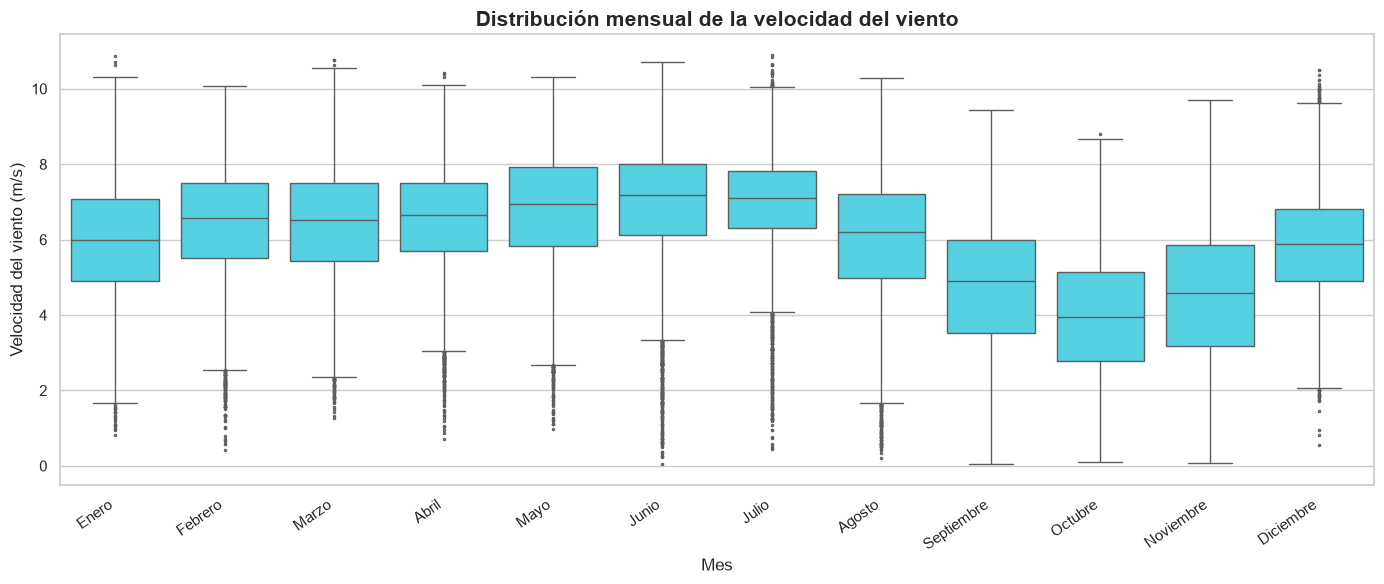

In [14]:
#Boxplot mensual para evaluar la variabilidad
orden_meses = list(nombres_meses.values())
serie_boxplot = analisis.reset_index()
serie_boxplot["Mes"] = serie_boxplot["Mes"].map(nombres_meses)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=serie_boxplot,
    x="Mes",
    y=variable,
    order=orden_meses,
    color="#3EE2F8",
    fliersize=1.5
)
plt.title("Distribución mensual de la velocidad del viento", fontsize=15, weight="bold")
plt.xlabel("Mes")
plt.ylabel(f"Velocidad del viento ({unidad})")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

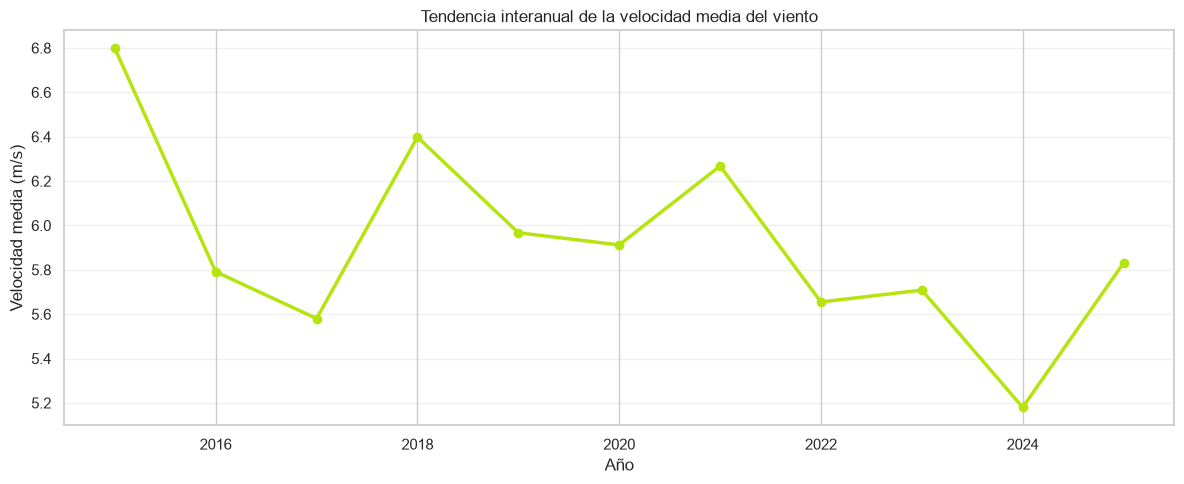

Cambio lineal estimado: -0.073 m/s/año


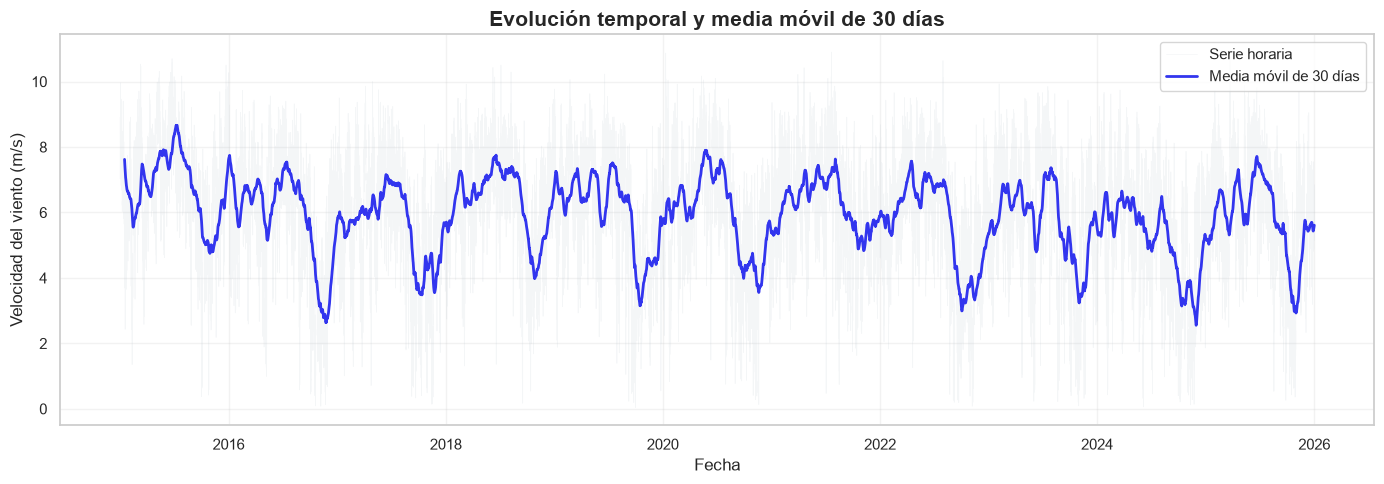

In [15]:
# 7. Tendencia temporal del recurso eólico
promedio_anual["Promedio"].plot(
    figsize=(12, 5),
    marker="o",
    linewidth=2.5,
    color="#B6E40F",
    title="Tendencia interanual de la velocidad media del viento"
)
plt.xlabel("Año")
plt.ylabel(f"Velocidad media ({unidad})")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Tendencia lineal: cuantifica el cambio medio por año.
anios = promedio_anual.index.to_numpy(dtype=float)
valores_anuales = promedio_anual["Promedio"].to_numpy()
pendiente, intercepto = np.polyfit(anios, valores_anuales, 1)
print(f"Cambio lineal estimado: {pendiente:+.3f} {unidad}/año")

# Media móvil de 30 días para visualizar la evolución de la serie horaria.
media_movil = analisis[variable].rolling("30D", min_periods=24 * 15).mean()
plt.figure(figsize=(14, 5))
plt.plot(analisis.index, analisis[variable], color="#B8C4CE", alpha=0.15, linewidth=0.5)
plt.plot(media_movil.index, media_movil, color="#3235EE", linewidth=2)
plt.title("Evolución temporal y media móvil de 30 días", fontsize=15, weight="bold")
plt.xlabel("Fecha")
plt.ylabel(f"Velocidad del viento ({unidad})")
plt.legend(["Serie horaria", "Media móvil de 30 días"])
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Calidad y continuidad de los datos

Antes de interpretar el recurso eólico, verificamos si la serie horaria presenta continuidad temporal y si existen valores atípicos o faltantes. Esto permite que las conclusiones sobre la variabilidad sean más confiables.


Registros esperados por frecuencia horaria: 96,432
Registros disponibles: 96,432
Marcas de tiempo faltantes: 0
Porcentaje de cobertura temporal: 100.00%
Valor mínimo observado: 0.04 m/s
Valor máximo observado: 10.90 m/s


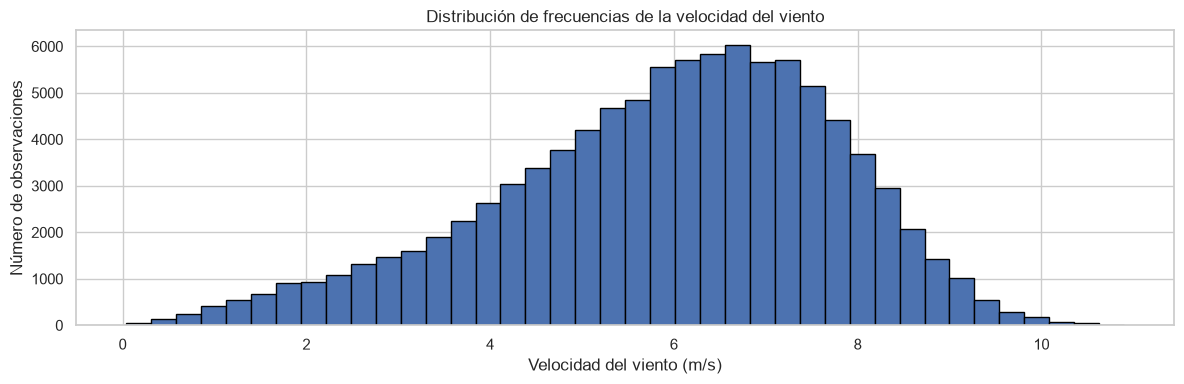

In [16]:
# 8. Calidad y continuidad de la serie horaria
serie = analisis[variable].copy()

indice_completo = pd.date_range(
    start=serie.index.min(),
    end=serie.index.max(),
    freq="h"
)

faltantes_temporales = indice_completo.difference(serie.index)
cobertura_pct = len(serie) / len(indice_completo) * 100

print(f"Registros esperados por frecuencia horaria: {len(indice_completo):,}")
print(f"Registros disponibles: {len(serie):,}")
print(f"Marcas de tiempo faltantes: {len(faltantes_temporales):,}")
print(f"Porcentaje de cobertura temporal: {cobertura_pct:.2f}%")

# Valores extremos para revisión descriptiva
print(f"Valor mínimo observado: {serie.min():.2f} m/s")
print(f"Valor máximo observado: {serie.max():.2f} m/s")

plt.figure(figsize=(12, 4))
plt.hist(serie, bins=40, edgecolor="black")
plt.title("Distribución de frecuencias de la velocidad del viento")
plt.xlabel("Velocidad del viento (m/s)")
plt.ylabel("Número de observaciones")
plt.tight_layout()
plt.show()

## Variabilidad temporal: comportamiento por hora del día

La generación eólica no depende únicamente del promedio general. También es importante observar cómo cambia la velocidad del viento durante el día, porque una concentración de mayores velocidades en determinadas horas puede modificar el comportamiento operativo de una instalación.


,Promedio,Desviacion,Minimo,Maximo
Hora,,,,
0,5.621,1.804,0.39,9.87
1,5.556,1.787,0.44,9.61
2,5.507,1.768,0.43,9.59
3,5.463,1.753,0.13,9.71
4,5.357,1.735,0.06,9.66
5,5.227,1.723,0.10,9.50
6,5.623,1.727,0.08,9.88
7,6.361,1.759,0.15,10.15
8,6.677,1.810,0.09,10.66


Hora con mayor velocidad promedio: 9:00 (6.68 m/s)
Hora con menor velocidad promedio: 5:00 (5.23 m/s)
Amplitud del ciclo diario: 1.46 m/s


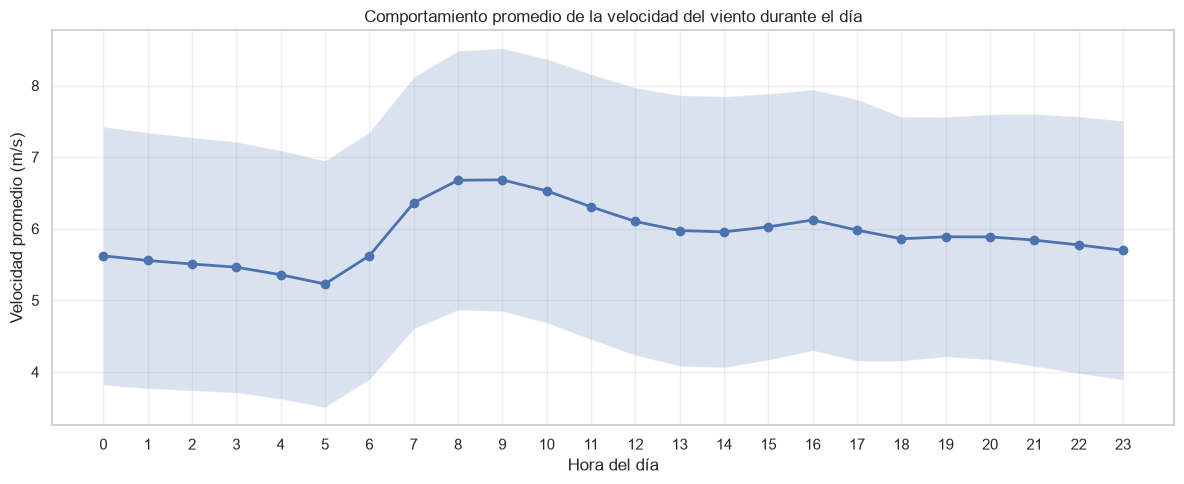

In [17]:
# 9. Ciclo diario promedio
analisis["Hora"] = analisis.index.hour

promedio_horario = (
    analisis.groupby("Hora")[variable]
    .agg(Promedio="mean", Desviacion="std", Minimo="min", Maximo="max")
)

hora_pico = promedio_horario["Promedio"].idxmax()
hora_valle = promedio_horario["Promedio"].idxmin()
amplitud_diaria = promedio_horario["Promedio"].max() - promedio_horario["Promedio"].min()

display(promedio_horario.round(3))
print(f"Hora con mayor velocidad promedio: {hora_pico}:00 ({promedio_horario.loc[hora_pico, 'Promedio']:.2f} m/s)")
print(f"Hora con menor velocidad promedio: {hora_valle}:00 ({promedio_horario.loc[hora_valle, 'Promedio']:.2f} m/s)")
print(f"Amplitud del ciclo diario: {amplitud_diaria:.2f} m/s")

plt.figure(figsize=(12, 5))
plt.plot(
    promedio_horario.index,
    promedio_horario["Promedio"],
    marker="o",
    linewidth=2
)
plt.fill_between(
    promedio_horario.index,
    promedio_horario["Promedio"] - promedio_horario["Desviacion"],
    promedio_horario["Promedio"] + promedio_horario["Desviacion"],
    alpha=0.2
)
plt.title("Comportamiento promedio de la velocidad del viento durante el día")
plt.xlabel("Hora del día")
plt.ylabel("Velocidad promedio (m/s)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Frecuencia de velocidades útiles para generación

Como la pregunta principal busca relacionar el recurso eólico con el potencial de generación eléctrica, calculamos qué proporción del tiempo la velocidad se encuentra por encima de diferentes umbrales. Estos umbrales son únicamente referencias de análisis y no sustituyen la curva de potencia de una turbina específica.


,Porcentaje
Velocidad_Viento,
< 2 m/s,3.26
2–4 m/s,12.19
4–6 m/s,31.44
6–8 m/s,41.60
8–10 m/s,11.32
10–12 m/s,0.18
>= 12 m/s,0.00


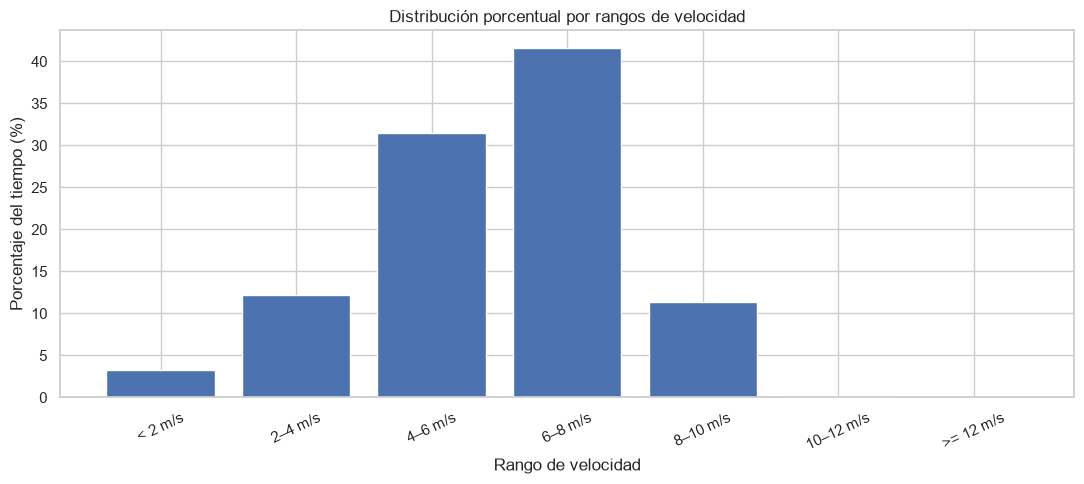

Tiempo con velocidad >= 3 m/s: 92.16%
Tiempo con velocidad >= 4 m/s: 84.55%
Tiempo con velocidad >= 5 m/s: 71.59%
Tiempo con velocidad >= 6 m/s: 53.11%
Tiempo con velocidad >= 8 m/s: 11.50%


In [18]:
# 10. Frecuencia de ocurrencia por rangos de velocidad
rangos = [-np.inf, 2, 4, 6, 8, 10, 12, np.inf]
etiquetas = [
    "< 2 m/s", "2–4 m/s", "4–6 m/s", "6–8 m/s",
    "8–10 m/s", "10–12 m/s", ">= 12 m/s"
]

categorias = pd.cut(
    serie,
    bins=rangos,
    labels=etiquetas,
    right=False
)

frecuencia_velocidad = (
    categorias.value_counts(normalize=True, sort=False)
    .mul(100)
    .rename("Porcentaje")
    .to_frame()
)

display(frecuencia_velocidad.round(2))

plt.figure(figsize=(11, 5))
plt.bar(frecuencia_velocidad.index.astype(str), frecuencia_velocidad["Porcentaje"])
plt.title("Distribución porcentual por rangos de velocidad")
plt.xlabel("Rango de velocidad")
plt.ylabel("Porcentaje del tiempo (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

for umbral in [3, 4, 5, 6, 8]:
    porcentaje = (serie >= umbral).mean() * 100
    print(f"Tiempo con velocidad >= {umbral} m/s: {porcentaje:.2f}%")


## Densidad de potencia eólica: aproximación física

La potencia disponible en el viento depende aproximadamente de la densidad del aire y del cubo de la velocidad:

**P = 1/2 · ρ · v³**

Con los datos disponibles podemos calcular la densidad de potencia eólica promedio como indicador del recurso. Este cálculo se realiza con **WS2M**, por lo que representa una aproximación a 2 metros de altura. Para estimar una altura de buje se puede aplicar una ley de potencia, pero debe entenderse como un escenario y no como una medición directa.


Densidad de potencia eólica promedio a 2 m: 161.54 W/m²


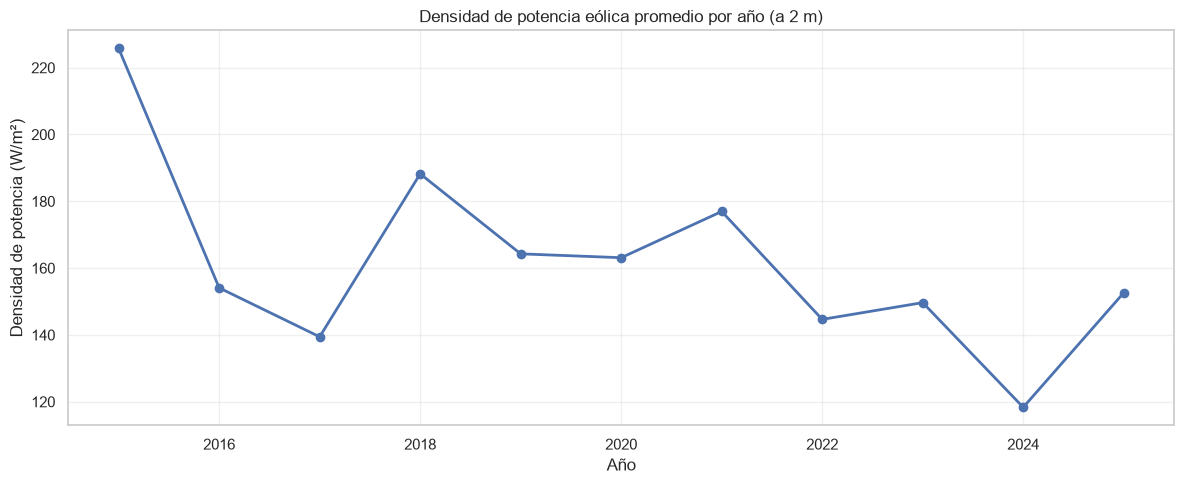

In [19]:
# 11. Densidad de potencia eólica a 2 m
rho = 1.225  # kg/m³, densidad del aire de referencia
v = serie

potencia_instante = 0.5 * rho * (v ** 3)  # W/m²
densidad_potencia_media = potencia_instante.mean()

print(f"Densidad de potencia eólica promedio a 2 m: {densidad_potencia_media:.2f} W/m²")

# Comparación por año
potencia_anual = potencia_instante.groupby(potencia_instante.index.year).mean()

plt.figure(figsize=(12, 5))
plt.plot(potencia_anual.index, potencia_anual.values, marker="o", linewidth=2)
plt.title("Densidad de potencia eólica promedio por año (a 2 m)")
plt.xlabel("Año")
plt.ylabel("Densidad de potencia (W/m²)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Escenario de extrapolación a una altura de buje

Los datos descargados corresponden a 2 m. Para mostrar cómo cambia la velocidad con la altura, usamos la ley de potencia:

**V(z) = V(z₀) · (z/z₀)^α**

Se adopta α = 0.14 únicamente como supuesto de escenario. Para un estudio de ingeniería se debería justificar este parámetro con mediciones locales, rugosidad del terreno y condiciones atmosféricas.


Altura 50 m -> velocidad media aproximada: 9.29 m/s | densidad de potencia aproximada: 624.34 W/m²
Altura 100 m -> velocidad media aproximada: 10.23 m/s | densidad de potencia aproximada: 835.32 W/m²


,velocidad_media,wpd_media
Altura_m,,
2,5.92,161.54
50,9.29,624.34
100,10.23,835.32


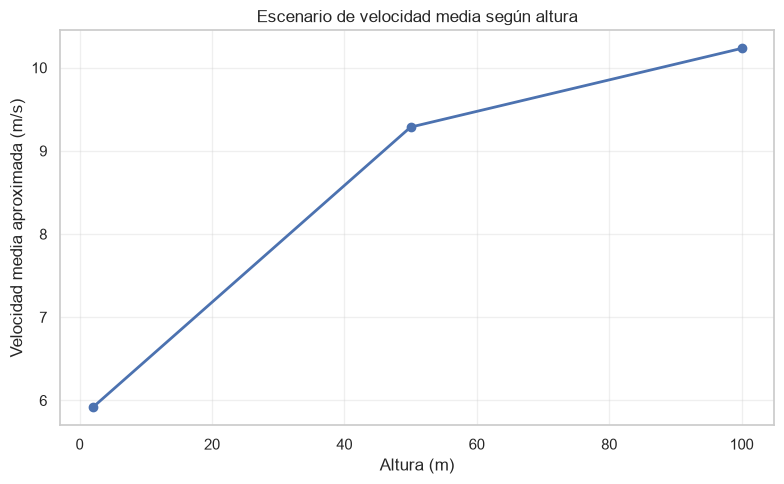

In [20]:
# 12. Escenario de extrapolación de velocidad a 50 m y 100 m
z0 = 2.0
alpha = 0.14

resultados_alturas = {2: {"velocidad_media": serie.mean(), "wpd_media": densidad_potencia_media}}

for z in [50, 100]:
    factor = (z / z0) ** alpha
    velocidad_extrapolada = serie * factor
    wpd_extrapolada = 0.5 * rho * (velocidad_extrapolada ** 3)

    resultados_alturas[z] = {
        "velocidad_media": velocidad_extrapolada.mean(),
        "wpd_media": wpd_extrapolada.mean(),
    }

    print(
        f"Altura {z} m -> velocidad media aproximada: "
        f"{velocidad_extrapolada.mean():.2f} m/s | "
        f"densidad de potencia aproximada: {wpd_extrapolada.mean():.2f} W/m²"
    )

tabla_alturas = pd.DataFrame(resultados_alturas).T
tabla_alturas.index.name = "Altura_m"
display(tabla_alturas.round(2))

# Comparación visual
alturas = np.array(list(resultados_alturas.keys()))
vel_medias = np.array([v["velocidad_media"] for v in resultados_alturas.values()])

plt.figure(figsize=(8, 5))
plt.plot(alturas, vel_medias, marker="o", linewidth=2)
plt.title("Escenario de velocidad media según altura")
plt.xlabel("Altura (m)")
plt.ylabel("Velocidad media aproximada (m/s)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Comparación entre años y meses

Para responder directamente la pregunta principal, resumimos el comportamiento temporal en tres dimensiones: promedio, variabilidad y frecuencia de velocidades relativamente altas. Así podemos distinguir entre tener una velocidad media alta y tener un recurso estable.


In [21]:
# 13. Resumen de indicadores para apoyar la conclusión
resumen_anual = promedio_anual[["Promedio", "Desviacion"]].copy()
resumen_anual["CV_%"] = resumen_anual["Desviacion"] / resumen_anual["Promedio"] * 100
resumen_anual[">=6_m_s_%"] = (
    analisis[variable].ge(6).groupby(analisis["Año"]).mean() * 100
)
resumen_anual["Potencia_W_m2"] = (
    0.5 * rho * analisis[variable].pow(3).groupby(analisis["Año"]).mean()
)

display(resumen_anual.round(3))

print("Año con mayor densidad de potencia promedio:",
      resumen_anual["Potencia_W_m2"].idxmax())
print("Año con menor densidad de potencia promedio:",
      resumen_anual["Potencia_W_m2"].idxmin())


,Promedio,Desviacion,CV_%,>=6_m_s_%,Potencia_W_m2
Año,,,,,
2015,6.798,1.671,24.576,71.461,225.767
2016,5.791,1.875,32.369,50.512,154.092
2017,5.580,1.843,33.034,45.822,139.434
2018,6.398,1.582,24.720,65.902,188.216
2019,5.967,1.815,30.410,54.840,164.268
2020,5.912,1.869,31.607,50.786,163.115
2021,6.268,1.521,24.267,59.783,176.952
2022,5.655,1.856,32.813,48.379,144.649
2023,5.709,1.905,33.373,49.326,149.668


Año con mayor densidad de potencia promedio: 2015
Año con menor densidad de potencia promedio: 2024


## Conclusión orientada a la pregunta principal

Con los resultados anteriores, la conclusión debe responde a:

1. ¿Cómo se comporta la velocidad del viento en La Guajira durante el periodo estudiado?
2. ¿Qué tan variable es entre meses, horas y años?
3. ¿Qué implicación tiene esa variabilidad sobre el potencial de generación?
4. ¿Qué limitaciones tiene el análisis?

**Observación:** este proyecto permite evaluar el recurso eólico y construir indicadores físicos aproximados, pero no permite calcular una producción eléctrica real de un parque sin conocer, entre otros elementos, la curva de potencia de la turbina, altura de buje, disponibilidad, pérdidas y características específicas del sitio.

A continuación se presenta primero un resumen numérico general y luego una conclusión narrativa, construida automáticamente a partir de los indicadores ya calculados en este notebook, que responde punto por punto a las cuatro preguntas anteriores.

In [22]:
# 14. Indicadores finales para presentar
media_general = serie.mean()
mediana_general = serie.median()
cv_general = serie.std() / media_general * 100
p_ge_6 = (serie >= 6).mean() * 100
p_ge_8 = (serie >= 8).mean() * 100

print("========== RESUMEN DEL RECURSO EÓLICO ==========")
print(f"Periodo: {serie.index.min():%Y-%m-%d} a {serie.index.max():%Y-%m-%d}")
print(f"Velocidad media: {media_general:.2f} m/s")
print(f"Velocidad mediana: {mediana_general:.2f} m/s")
print(f"Coeficiente de variación: {cv_general:.2f}%")
print(f"Tiempo con viento >= 6 m/s: {p_ge_6:.2f}%")
print(f"Tiempo con viento >= 8 m/s: {p_ge_8:.2f}%")
print(f"Densidad de potencia promedio a 2 m: {densidad_potencia_media:.2f} W/m²")
print(f"Mejor año por velocidad media: {mejor_anio}")
print(f"Peor año por velocidad media: {peor_anio}")
print(f"Mejor mes climatológico: {nombres_meses[mejor_mes_numero]}")
print(f"Peor mes climatológico: {nombres_meses[peor_mes_numero]}")


========== RESUMEN DEL RECURSO EÓLICO ==========
Periodo: 2015-01-01 a 2025-12-31
Velocidad media: 5.92 m/s
Velocidad mediana: 6.14 m/s
Coeficiente de variación: 30.99%
Tiempo con viento >= 6 m/s: 53.11%
Tiempo con viento >= 8 m/s: 11.50%
Densidad de potencia promedio a 2 m: 161.54 W/m²
Mejor año por velocidad media: 2015
Peor año por velocidad media: 2024
Mejor mes climatológico: Julio
Peor mes climatológico: Octubre


## Conclusión final

In [23]:
from IPython.display import Markdown, display as display_md

# Redacción de la tendencia interanual en palabras, a partir de la pendiente ya calculada
if pendiente > 0:
    texto_tendencia = f"un leve aumento de {pendiente:.3f} {unidad} por año"
elif pendiente < 0:
    texto_tendencia = f"una leve disminución de {abs(pendiente):.3f} {unidad} por año"
else:
    texto_tendencia = "una tendencia prácticamente estable"

anio_mayor_potencia = resumen_anual["Potencia_W_m2"].idxmax()
anio_menor_potencia = resumen_anual["Potencia_W_m2"].idxmin()

velocidad_100m = resultados_alturas[100]["velocidad_media"]
wpd_100m = resultados_alturas[100]["wpd_media"]

conclusion_texto = f"""
### 1. Comportamiento del viento en La Guajira

Entre {serie.index.min():%Y-%m-%d} y {serie.index.max():%Y-%m-%d}, la velocidad media del viento a 2 m de altura
fue de **{media_general:.2f} {unidad}** (mediana {mediana_general:.2f} {unidad}), con una cobertura temporal de la
serie del **{cobertura_pct:.1f}%**.

### 2. Variabilidad temporal

- **Entre meses:** el mes con mayor velocidad promedio fue **{nombres_meses[mejor_mes_numero]}**
  ({promedio_mensual.loc[mejor_mes_numero, 'Promedio']:.2f} {unidad}) y el de menor velocidad fue
  **{nombres_meses[peor_mes_numero]}** ({promedio_mensual.loc[peor_mes_numero, 'Promedio']:.2f} {unidad}).
- **Entre horas del día:** la velocidad es mayor alrededor de las **{hora_pico}:00** y menor alrededor de las
  **{hora_valle}:00**, con una amplitud del ciclo diario de **{amplitud_diaria:.2f} {unidad}**.
- **Entre años:** {mejor_anio} fue el año con mayor velocidad media
  ({promedio_anual.loc[mejor_anio, 'Promedio']:.2f} {unidad}) y {peor_anio} el de menor velocidad
  ({promedio_anual.loc[peor_anio, 'Promedio']:.2f} {unidad}). La tendencia lineal de largo plazo muestra
  {texto_tendencia}.
- El coeficiente de variación general de **{cv_general:.2f}%** confirma una dispersión moderada-alta del recurso
  alrededor de su promedio.

### 3. Efecto sobre el potencial de generación de energía eléctrica

- El viento supera los 6 {unidad} el **{p_ge_6:.1f}%** del tiempo y los 8 {unidad} el **{p_ge_8:.1f}%** del tiempo;
  estos son rangos relevantes porque muchos aerogeneradores comerciales operan cerca de su potencia nominal en ese
  entorno de velocidades.
- La densidad de potencia eólica promedio a 2 m es de **{densidad_potencia_media:.1f} W/m²**. En el escenario de
  extrapolación a 100 m (altura típica de buje), la velocidad media pasaría a **{velocidad_100m:.2f} {unidad}** y la
  densidad de potencia a **{wpd_100m:.1f} W/m²**, lo que ilustra cómo el mismo recurso representa un potencial
  energético mucho mayor si se aprovecha a la altura adecuada.
- A nivel anual, **{anio_mayor_potencia}** fue el año con mayor densidad de potencia disponible y
  **{anio_menor_potencia}** el de menor, siguiendo el mismo patrón que la velocidad media anual: los periodos de
  menor recurso eólico se traducen directamente en un menor potencial de generación eléctrica, y viceversa.
- En conjunto, esto muestra que la variabilidad temporal del viento (diaria, mensual e interanual) es también
  variabilidad del potencial de generación: un parque eólico en esta ubicación tendría una producción con marcada
  estacionalidad, y no un aporte constante a lo largo del año o del día.

### 4. Limitaciones del análisis

- Los datos corresponden a `WS2M` (2 m de altura), muy por debajo de la altura de buje real de un aerogenerador; la
  extrapolación a 50 m y 100 m es solo un escenario ilustrativo con α = {alpha}, no una medición ni un estudio de
  micrositio.
- No se dispone de la dirección del viento, por lo que no fue posible construir una rosa de vientos.
- La densidad de potencia disponible **no equivale a energía eléctrica generada**: estimar una producción real
  requeriría la curva de potencia de una turbina específica, la disponibilidad del equipo, las pérdidas eléctricas
  y de estela, y las condiciones exactas del emplazamiento.
- La densidad del aire se asumió constante ({rho} kg/m³); en la práctica varía con la temperatura, la humedad y la
  presión atmosférica del sitio.
"""

display_md(Markdown(conclusion_texto))


### 1. Comportamiento del viento en La Guajira

Entre 2015-01-01 y 2025-12-31, la velocidad media del viento a 2 m de altura
fue de **5.92 m/s** (mediana 6.14 m/s), con una cobertura temporal de la
serie del **100.0%**.

### 2. Variabilidad temporal

- **Entre meses:** el mes con mayor velocidad promedio fue **Julio**
  (6.99 m/s) y el de menor velocidad fue
  **Octubre** (3.98 m/s).
- **Entre horas del día:** la velocidad es mayor alrededor de las **9:00** y menor alrededor de las
  **5:00**, con una amplitud del ciclo diario de **1.46 m/s**.
- **Entre años:** 2015 fue el año con mayor velocidad media
  (6.80 m/s) y 2024 el de menor velocidad
  (5.18 m/s). La tendencia lineal de largo plazo muestra
  una leve disminución de 0.073 m/s por año.
- El coeficiente de variación general de **30.99%** confirma una dispersión moderada-alta del recurso
  alrededor de su promedio.

### 3. Efecto sobre el potencial de generación de energía eléctrica

- El viento supera los 6 m/s el **53.1%** del tiempo y los 8 m/s el **11.5%** del tiempo;
  estos son rangos relevantes porque muchos aerogeneradores comerciales operan cerca de su potencia nominal en ese
  entorno de velocidades.
- La densidad de potencia eólica promedio a 2 m es de **161.5 W/m²**. En el escenario de
  extrapolación a 100 m (altura típica de buje), la velocidad media pasaría a **10.23 m/s** y la
  densidad de potencia a **835.3 W/m²**, lo que ilustra cómo el mismo recurso representa un potencial
  energético mucho mayor si se aprovecha a la altura adecuada.
- A nivel anual, **2015** fue el año con mayor densidad de potencia disponible y
  **2024** el de menor, siguiendo el mismo patrón que la velocidad media anual: los periodos de
  menor recurso eólico se traducen directamente en un menor potencial de generación eléctrica, y viceversa.
- En conjunto, esto muestra que la variabilidad temporal del viento (diaria, mensual e interanual) es también
  variabilidad del potencial de generación: un parque eólico en esta ubicación tendría una producción con marcada
  estacionalidad, y no un aporte constante a lo largo del año o del día.

### 4. Limitaciones del análisis

- Los datos corresponden a `WS2M` (2 m de altura), muy por debajo de la altura de buje real de un aerogenerador; la
  extrapolación a 50 m y 100 m es solo un escenario ilustrativo con α = 0.14, no una medición ni un estudio de
  micrositio.
- No se dispone de la dirección del viento, por lo que no fue posible construir una rosa de vientos.
- La densidad de potencia disponible **no equivale a energía eléctrica generada**: estimar una producción real
  requeriría la curva de potencia de una turbina específica, la disponibilidad del equipo, las pérdidas eléctricas
  y de estela, y las condiciones exactas del emplazamiento.
- La densidad del aire se asumió constante (1.225 kg/m³); en la práctica varía con la temperatura, la humedad y la
  presión atmosférica del sitio.


# Recomendación:

La Guajira sigue siendo un sitio favorable para proyectos eólicos, en línea con los parques que ya operan allí, pero cualquier decisión de inversión debe anticipar la intermitencia, es decir que la generación no será uniforme todo el año ni todo el día.

Por eso recomendamos pensar la energía eólica en La Guajira en complementariedad con otras fuentes como la hidroeléctrica o la solar o con almacenamiento, para compensar los periodos de menor viento.

Para una decisión de inversión real, no basta con este análisis: se necesitarían mediciones a la altura real del aerogenerador, no una extrapolación, la curva de potencia de una turbina específica, y datos de disponibilidad y pérdidas del sistema.

Como la tendencia interanual del viento puede cambiar, recomendamos monitorear el recurso a largo plazo antes de dimensionar nuevos proyectos, en lugar de basarse solo en uno o dos años de referencia.